# Task 2: Exploratory Data Analysis (EDA)
### Netflix Movies and TV Shows

**Dataset:** [Netflix Movies and TV Shows — Kaggle](https://www.kaggle.com/datasets/shivamb/netflix-shows)

This notebook cleans the raw Netflix catalogue export, explores it with 7 plots, digs into the multi-valued `listed_in` (genre) column, tracks how the catalogue changed year over year, and closes with a plain-English summary of what the data shows.

**Structure**
1. Setup & Load
2. First Look at the Data
3. Data Quality Check (missing values, duplicates)
4. Data Cleaning
5. Feature Engineering (splitting `listed_in`, parsing `duration`, `date_added`)
6. Exploratory Visualizations (5+ plots)
7. Multi-valued Column Analysis (Genres)
8. Content Over Time (year-by-year comparison)
9. Brownie Points: Outlier check + Chi-square test
10. Save cleaned dataset
11. Insights (README-style summary)


## 1. Setup & Load

If you're running this in **Google Colab**, upload `netflix_titles.csv` (from the Kaggle link above) to the Colab file browser, or mount Google Drive and update the path below.

In [26]:
# Install/import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# consistent, attractive plot styling (matches ML Bootcamp conventions)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold'
})


In [27]:
# ---- Load the dataset ----
# In Colab: upload netflix_titles.csv, then this relative path will work.
# Alternatively, uncomment the two lines below to upload interactively:
# from google.colab import files
# uploaded = files.upload()

df = pd.read_csv("netflix_titles.csv")
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded dataset: 8807 rows, 12 columns


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## 2. First Look at the Data

In [28]:
print("Column info:")
df.info()

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [29]:
print("Summary statistics (numeric columns):")
df.describe()

Summary statistics (numeric columns):


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [30]:
# What are we working with?
print(f"Movies vs TV Shows breakdown:\n{df['type'].value_counts()}\n")
print(f"Release years span: {df['release_year'].min()} - {df['release_year'].max()}")

Movies vs TV Shows breakdown:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Release years span: 1925 - 2021


## 3. Data Quality Check

Before cleaning anything, let's quantify exactly how messy this dataset is: missing values, exact duplicate rows, and duplicate titles.

In [31]:
# --- Missing values ---
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary = missing_summary[missing_summary['missing_count'] > 0].sort_values('missing_count', ascending=False)
print("Missing values by column:")
missing_summary

Missing values by column:


,missing_count,missing_pct
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


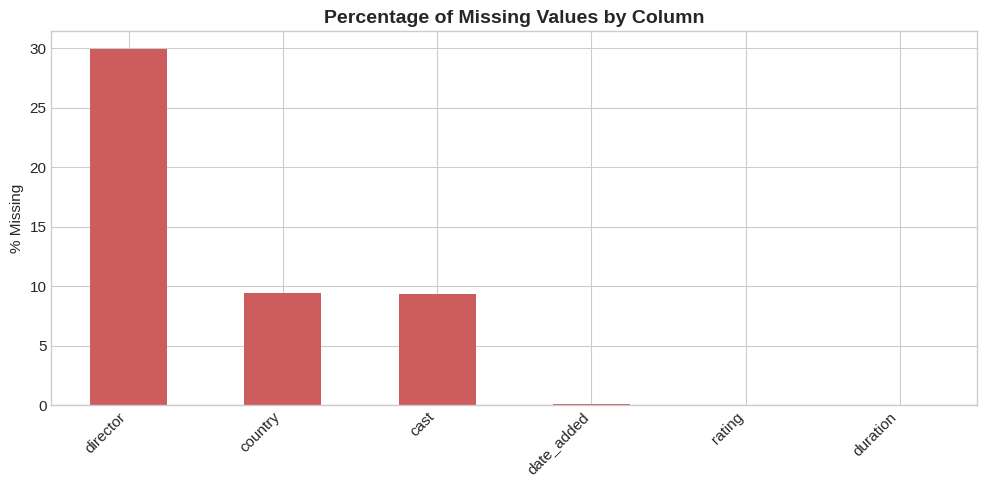

In [32]:
# visualize missingness
fig, ax = plt.subplots(figsize=(10, 5))
missing_summary['missing_pct'].plot(kind='bar', ax=ax, color='indianred')
ax.set_title('Percentage of Missing Values by Column')
ax.set_ylabel('% Missing')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [33]:
# --- Duplicate rows ---
exact_dupes = df.duplicated().sum()
title_type_country_dupes = df.duplicated(subset=['title', 'type', 'country']).sum()
print(f"Exact duplicate rows: {exact_dupes}")
print(f"Duplicate on (title, type, country): {title_type_country_dupes}")

Exact duplicate rows: 0
Duplicate on (title, type, country): 0


**Finding something 'off' in the data (Brownie Points):**

The `duration` column mixes two different units in the same column: movies are measured in minutes (`"90 min"`) while TV shows are measured in seasons (`"2 Seasons"`). If you naively tried to convert this whole column to a number, every TV show row would either error out or silently become `NaN`. We handle this explicitly below by splitting `duration` into a numeric value + a unit column, so a `1 Season` show doesn't get confused with a `1 min` short film.

## 4. Data Cleaning

Cleaning strategy (documented so the reasoning is clear):
- `director`, `cast`, `country`: fill missing with `'Unknown'` — dropping ~30% of rows just because a director wasn't listed would throw away too much useful data.
- `rating`: only 4 rows missing — fill with the mode (the most common rating).
- `duration`: only 3 rows missing — safe to drop those rows.
- `date_added`: only 10 rows missing/unparseable — safe to drop those rows since we need real dates for the time-based analysis.
- Remove exact duplicate rows (if any).

In [34]:
# work on a copy so we always have the raw df to compare against
df_clean = df.copy()

# 1) drop exact duplicate rows
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - df_clean.shape[0]} exact duplicate rows")

# 2) fill categorical missing values with 'Unknown' instead of dropping the row
for col in ['director', 'cast', 'country']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# 3) rating: fill the handful of missing values with the mode
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].mode()[0])

# 4) duration: drop the few rows where it's missing (can't analyze runtime without it)
df_clean = df_clean.dropna(subset=['duration'])

# 5) date_added: parse to real datetime, drop rows that fail to parse
df_clean['date_added'] = df_clean['date_added'].str.strip()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'], errors='coerce')
df_clean = df_clean.dropna(subset=['date_added'])

print(f"\nFinal cleaned shape: {df_clean.shape}")
print(f"Remaining missing values:\n{df_clean.isnull().sum().sum()} total")

Dropped 0 exact duplicate rows

Final cleaned shape: (8794, 12)
Remaining missing values:
0 total


## 5. Feature Engineering

We derive a few new columns that make the rest of the EDA much easier:
- `year_added`, `month_added` — pulled out of `date_added` for time-based plots.
- `duration_num`, `duration_unit` — the `duration` column split into a number + a unit (`min` or `Season(s)`), so movies and TV shows can each be analyzed correctly on their own scale.
- `genres_list` — the multi-valued `listed_in` column split into a Python list, ready to be exploded into one row per genre.

In [35]:
# --- date-derived features ---
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month_name()

# --- split duration into a number and a unit (handles 'min' vs 'Season(s)' correctly) ---
df_clean['duration_num'] = df_clean['duration'].str.extract(r'(\d+)').astype(float)
df_clean['duration_unit'] = df_clean['duration'].str.extract(r'([a-zA-Z]+)')

# --- split the multi-valued 'listed_in' genre column into a real Python list ---
df_clean['genres_list'] = df_clean['listed_in'].str.split(', ')
df_clean['genre_count'] = df_clean['genres_list'].apply(len)

# --- split the multi-valued 'country' column too (some titles list several countries) ---
df_clean['country_list'] = df_clean['country'].str.split(', ')
df_clean['primary_country'] = df_clean['country_list'].apply(lambda x: x[0])

df_clean[['title', 'duration', 'duration_num', 'duration_unit', 'listed_in', 'genres_list', 'year_added']].head()

,title,duration,duration_num,duration_unit,listed_in,genres_list,year_added
0,Dick Johnson Is Dead,90 min,90.0,min,Documentaries,[Documentaries],2021
1,Blood & Water,2 Seasons,2.0,Seasons,"International TV Shows, TV Dramas, TV Mysteries","[International TV Shows, TV Dramas, TV Mysteries]",2021
2,Ganglands,1 Season,1.0,Season,"Crime TV Shows, International TV Shows, TV Act...","[Crime TV Shows, International TV Shows, TV Ac...",2021
3,Jailbirds New Orleans,1 Season,1.0,Season,"Docuseries, Reality TV","[Docuseries, Reality TV]",2021
4,Kota Factory,2 Seasons,2.0,Seasons,"International TV Shows, Romantic TV Shows, TV ...","[International TV Shows, Romantic TV Shows, TV...",2021


## 6. Exploratory Visualizations

Five-plus visualizations covering the shape of the catalogue: content type mix, top countries, ratings, runtimes, and genres.

### Plot 1 — Movies vs. TV Shows (Bar + Pie)

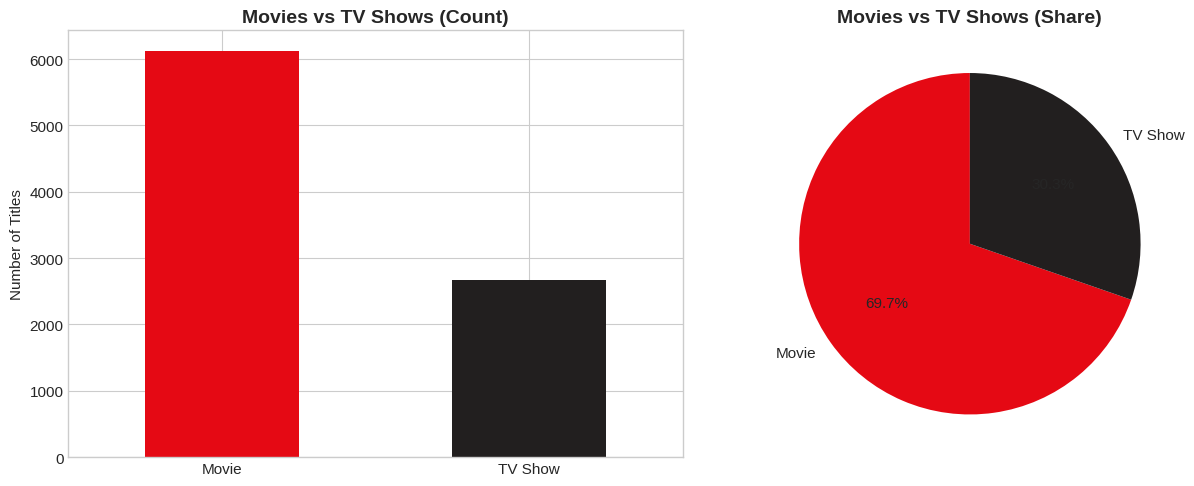

Movies make up 69.7% of the catalogue


In [36]:
type_counts = df_clean['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

type_counts.plot(kind='bar', ax=axes[0], color=['#e50914', '#221f1f'])
axes[0].set_title('Movies vs TV Shows (Count)')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Titles')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(type_counts, labels=type_counts.index, autopct='%1.1f%%',
            colors=['#e50914', '#221f1f'], startangle=90)
axes[1].set_title('Movies vs TV Shows (Share)')

plt.tight_layout()
plt.show()

print(f"Movies make up {type_counts['Movie']/type_counts.sum()*100:.1f}% of the catalogue")

### Plot 2 — Top 10 Content-Producing Countries

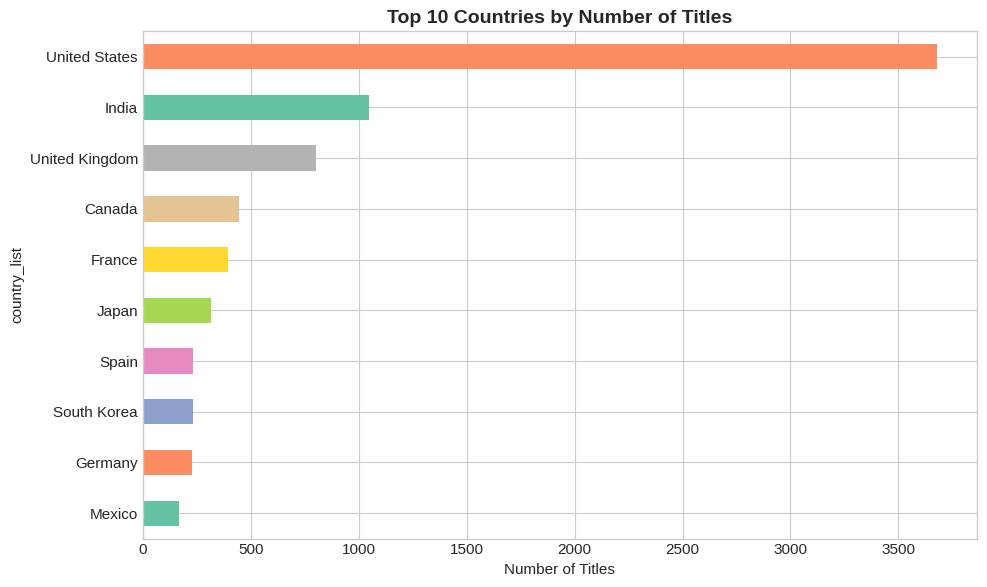

In [37]:
# use the split country list so co-productions count for every listed country
country_exploded = df_clean.explode('country_list')
country_exploded = country_exploded[country_exploded['country_list'] != 'Unknown']
top_countries = country_exploded['country_list'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_countries.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('Set2', 10))
ax.set_title('Top 10 Countries by Number of Titles')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()

### Plot 3 — Content Rating Distribution

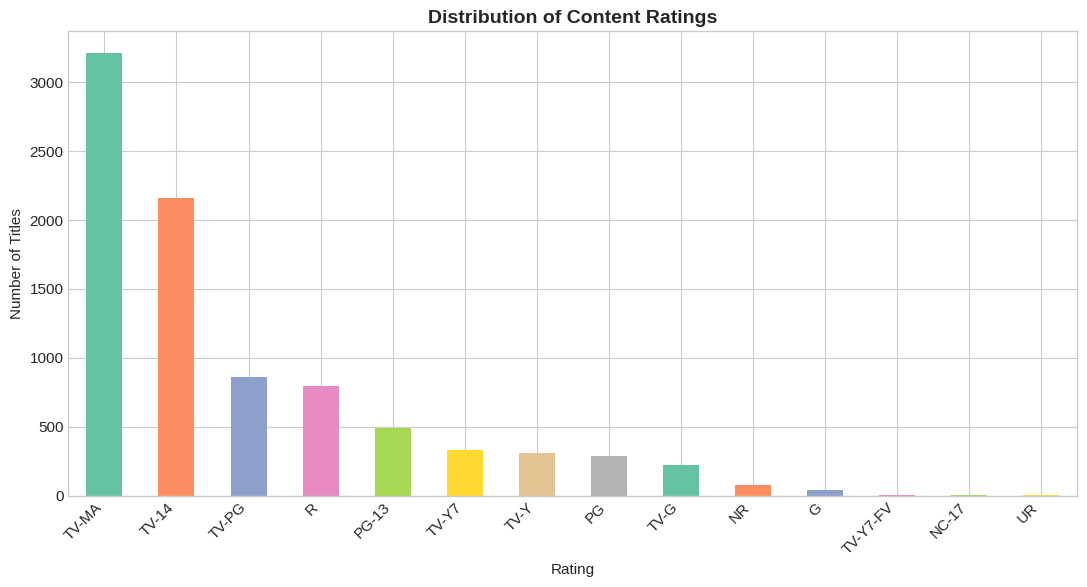

In [38]:
rating_counts = df_clean['rating'].value_counts()

fig, ax = plt.subplots(figsize=(11, 6))
rating_counts.plot(kind='bar', ax=ax, color=sns.color_palette('Set2', len(rating_counts)))
ax.set_title('Distribution of Content Ratings')
ax.set_xlabel('Rating')
ax.set_ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Plot 4 — Movie Duration Distribution (Histogram)

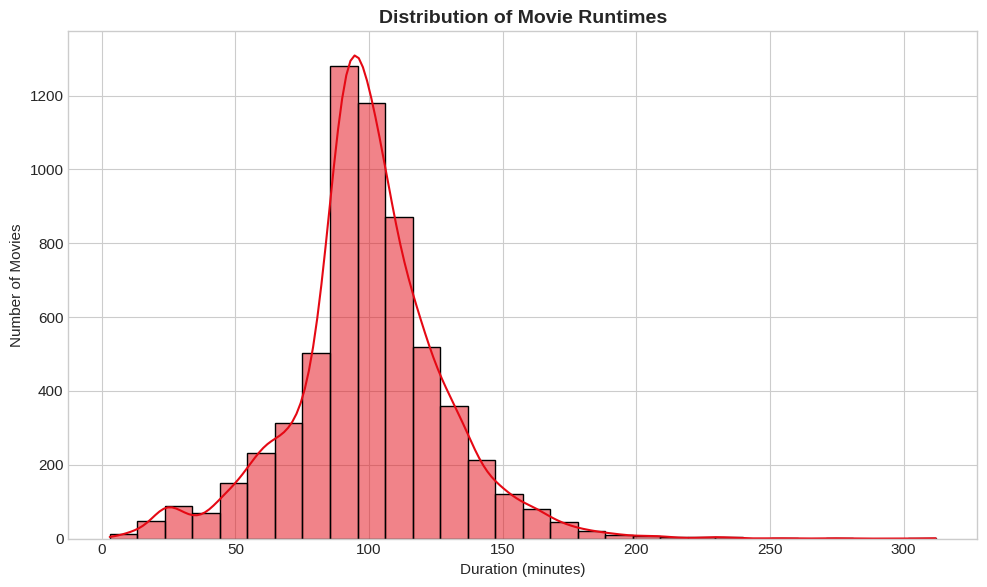

Average movie runtime: 99.6 minutes
Median movie runtime: 98.0 minutes


In [39]:
movies = df_clean[df_clean['type'] == 'Movie']

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(movies['duration_num'], bins=30, kde=True, color='#e50914', ax=ax)
ax.set_title('Distribution of Movie Runtimes')
ax.set_xlabel('Duration (minutes)')
ax.set_ylabel('Number of Movies')
plt.tight_layout()
plt.show()

print(f"Average movie runtime: {movies['duration_num'].mean():.1f} minutes")
print(f"Median movie runtime: {movies['duration_num'].median():.1f} minutes")

### Plot 5 — TV Show Length (Number of Seasons)

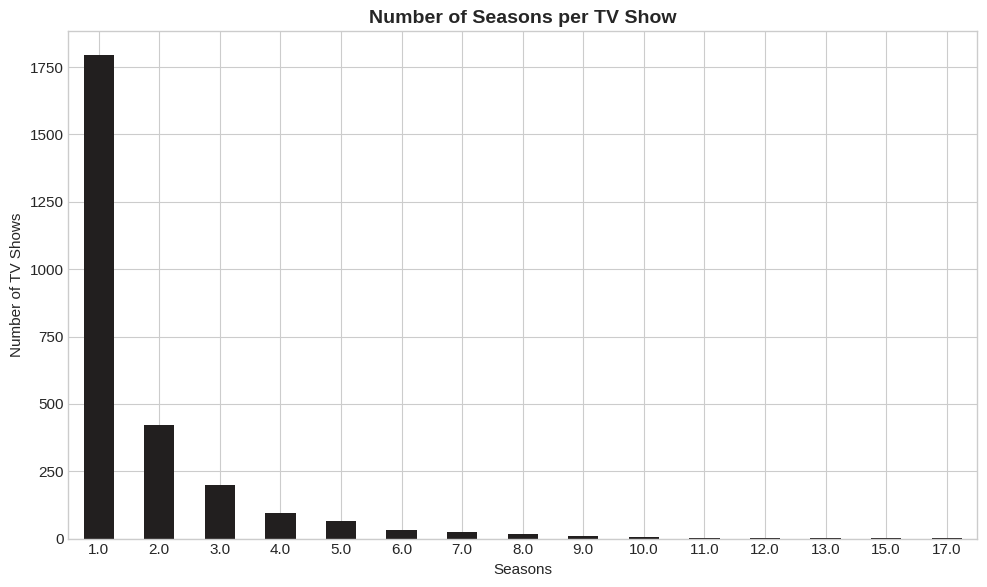

1793 out of 2666 TV shows (67.3%) only have 1 season


In [40]:
tv = df_clean[df_clean['type'] == 'TV Show']
season_counts = tv['duration_num'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
season_counts.plot(kind='bar', ax=ax, color='#221f1f')
ax.set_title('Number of Seasons per TV Show')
ax.set_xlabel('Seasons')
ax.set_ylabel('Number of TV Shows')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"{(tv['duration_num']==1).sum()} out of {len(tv)} TV shows ({(tv['duration_num']==1).mean()*100:.1f}%) only have 1 season")

## 7. Multi-Valued Column Analysis — Genres (`listed_in`)

`listed_in` often contains several genres per title (e.g. `"Dramas, International Movies"`). Treating this as one messy string would hide the real genre distribution, so we **explode** it into one row per (title, genre) pair before counting.

In [41]:
genres_exploded = df_clean.explode('genres_list')
print(f"Original rows: {len(df_clean)}  ->  After exploding genres: {len(genres_exploded)}")
print(f"Number of unique genres: {genres_exploded['genres_list'].nunique()}")

Original rows: 8794  ->  After exploding genres: 19300
Number of unique genres: 42


### Plot 6 — Top 10 Genres Overall

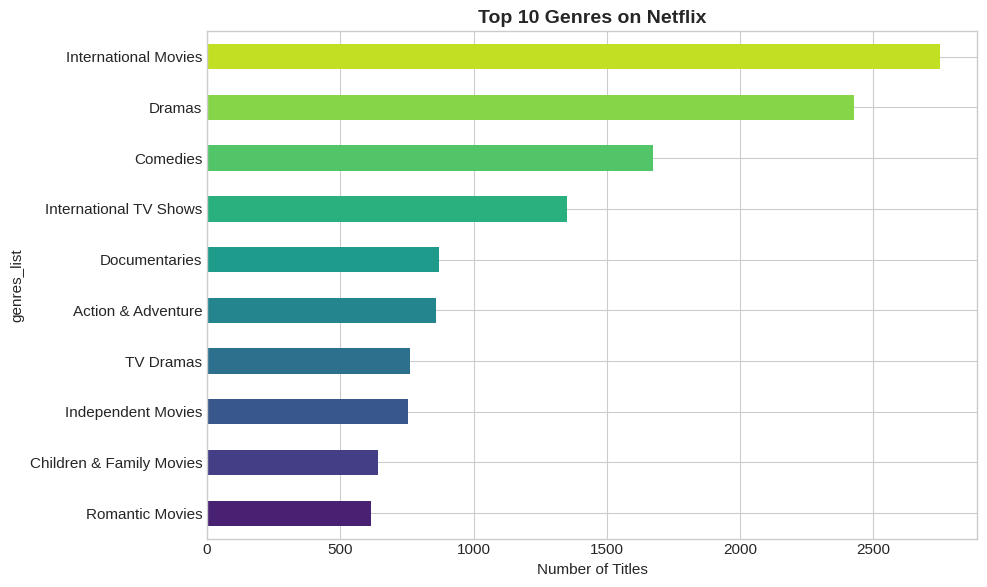

In [42]:
top_genres = genres_exploded['genres_list'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top_genres.sort_values().plot(kind='barh', ax=ax, color=sns.color_palette('viridis', 10))
ax.set_title('Top 10 Genres on Netflix')
ax.set_xlabel('Number of Titles')
plt.tight_layout()
plt.show()

### Plot 7 — Top Genres: Movies vs TV Shows Compared

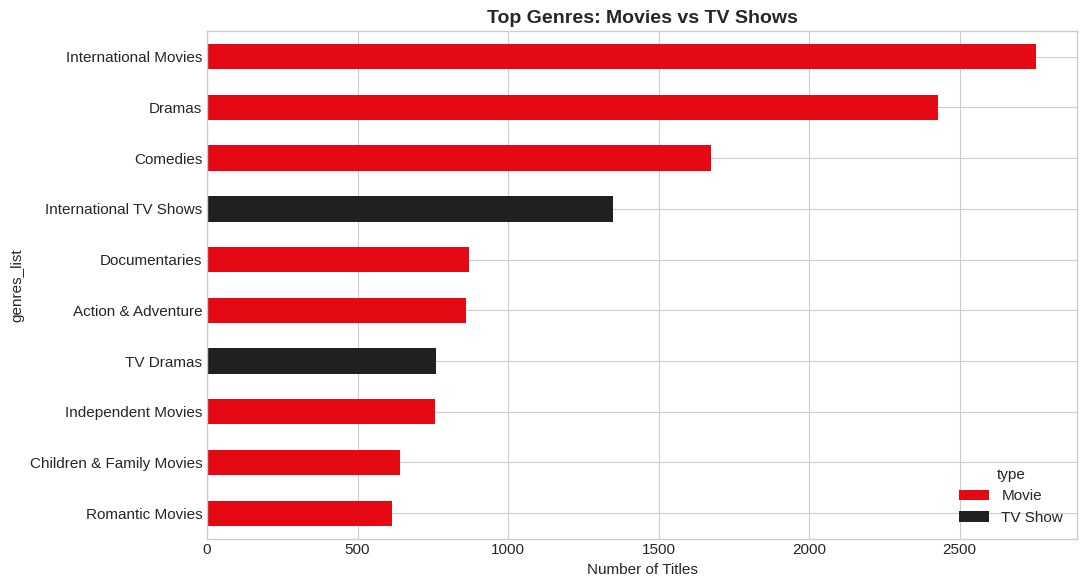

In [43]:
top_10_genre_names = top_genres.index.tolist()
genre_by_type = (genres_exploded[genres_exploded['genres_list'].isin(top_10_genre_names)]
                 .groupby(['genres_list', 'type']).size().unstack(fill_value=0)
                 .loc[top_10_genre_names])

fig, ax = plt.subplots(figsize=(11, 6))
genre_by_type.plot(kind='barh', stacked=True, ax=ax, color=['#e50914', '#221f1f'])
ax.set_title('Top Genres: Movies vs TV Shows')
ax.set_xlabel('Number of Titles')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** genres like *International Movies*, *Dramas*, and *Comedies* dominate the Movie side, while *International TV Shows*, *TV Dramas*, and *Crime TV Shows* dominate the TV side — the two catalogues lean into fairly different genre mixes.

## 8. Content Added Over Time (Year-by-Year Comparison)

This is the required **comparison over time**: how has the number of titles Netflix added changed year by year, and how does that breakdown between Movies and TV Shows?

### Plot 8 — Titles Added to Netflix per Year

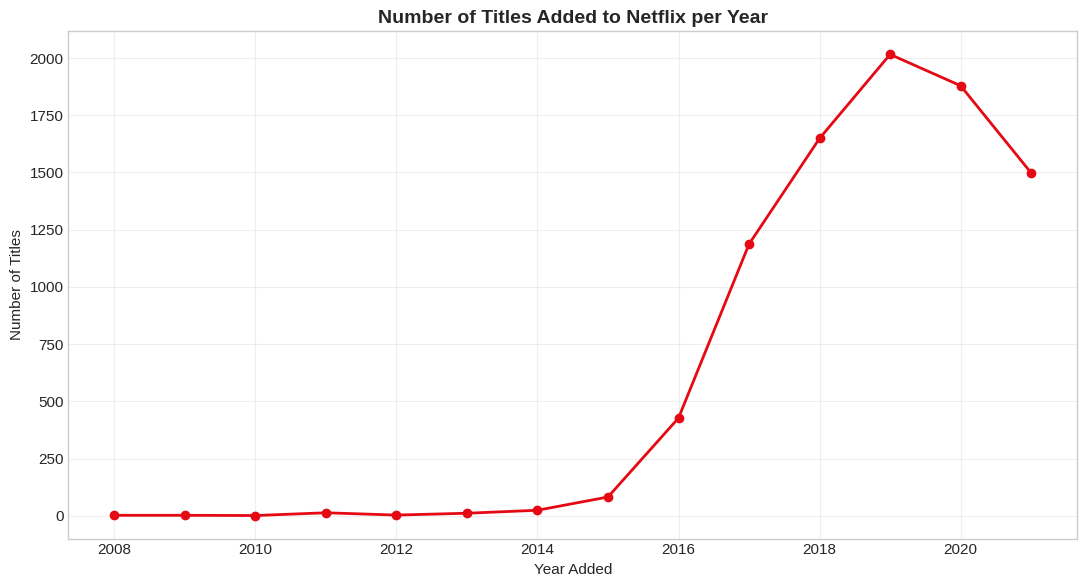

Peak year for additions: 2019 (2016 titles)


In [44]:
yearly_counts = df_clean.groupby('year_added').size()

fig, ax = plt.subplots(figsize=(11, 6))
yearly_counts.plot(kind='line', marker='o', ax=ax, color='#e50914', linewidth=2)
ax.set_title('Number of Titles Added to Netflix per Year')
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

peak_year = yearly_counts.idxmax()
print(f"Peak year for additions: {int(peak_year)} ({yearly_counts.max()} titles)")

### Plot 9 — Same Trend, Split by Movies vs TV Shows

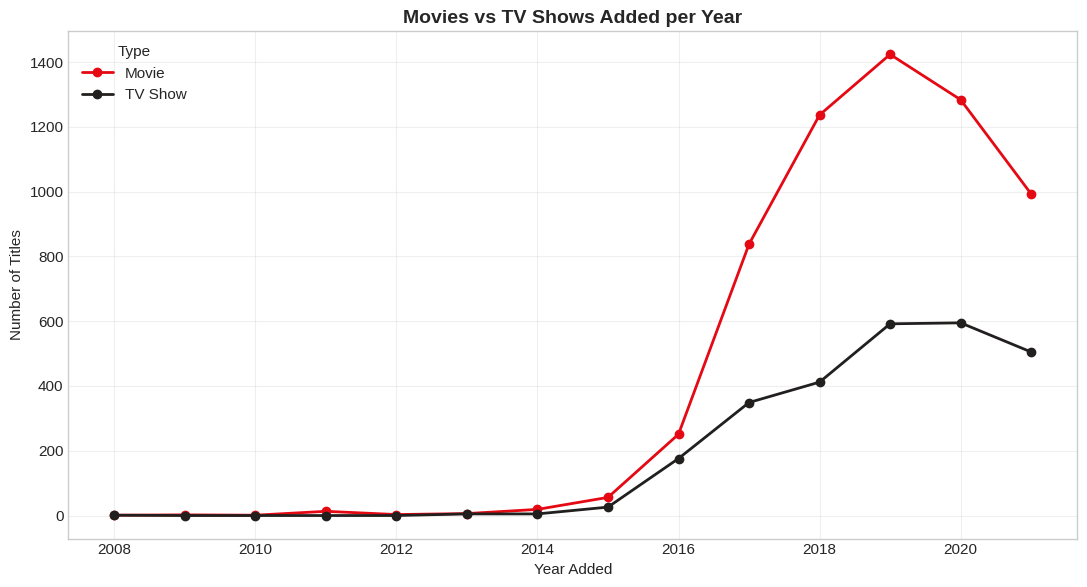

In [45]:
yearly_by_type = df_clean.groupby(['year_added', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(11, 6))
yearly_by_type.plot(kind='line', marker='o', ax=ax, color=['#e50914', '#221f1f'], linewidth=2)
ax.set_title('Movies vs TV Shows Added per Year')
ax.set_xlabel('Year Added')
ax.set_ylabel('Number of Titles')
ax.legend(title='Type')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Observation:** additions grew steadily and then accelerated sharply in the late 2010s (peaking around 2019), with TV Shows growing faster in *relative* terms than Movies over that same period — Netflix visibly shifted investment toward original/TV content as the catalogue matured.

## 9. Brownie Points

### 9a. Something that looked "off" in the data, and how it was handled

As flagged in Section 3, the `duration` column silently mixes two incompatible units: minutes for Movies and Seasons for TV Shows. A naive `pd.to_numeric(df['duration'])` would fail outright, and stripping just the digits without checking the unit would make a **1-season** TV show look identical to a **1-minute** short. We handled this by using a regex to split `duration` into `duration_num` (the number) and `duration_unit` (the label), and by always filtering to `type == 'Movie'` or `type == 'TV Show'` before doing any runtime math.

### 9b. Outlier Detection (IQR method) on Movie Runtimes

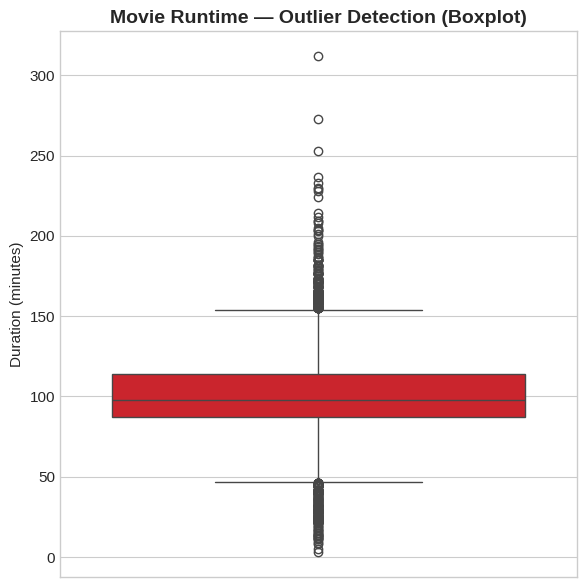

IQR bounds: [46.5, 154.5] minutes
Number of outlier movies: 450 (7.3% of all movies)

Shortest outliers:
                 title  duration_num
3777            Silent           3.0
2713       Sol Levante           5.0
1484  Cops and Robbers           8.0

Longest outliers:
                            title  duration_num
4253   Black Mirror: Bandersnatch         312.0
717   Headspace: Unwind Your Mind         273.0
2491       The School of Mischief         253.0


In [46]:
fig, ax = plt.subplots(figsize=(6, 6))
sns.boxplot(y=movies['duration_num'], ax=ax, color='#e50914')
ax.set_title('Movie Runtime — Outlier Detection (Boxplot)')
ax.set_ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

Q1 = movies['duration_num'].quantile(0.25)
Q3 = movies['duration_num'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = movies[(movies['duration_num'] < lower_bound) | (movies['duration_num'] > upper_bound)]
print(f"IQR bounds: [{lower_bound:.1f}, {upper_bound:.1f}] minutes")
print(f"Number of outlier movies: {len(outliers)} ({len(outliers)/len(movies)*100:.1f}% of all movies)")
print("\nShortest outliers:")
print(outliers.nsmallest(3, 'duration_num')[['title', 'duration_num']])
print("\nLongest outliers:")
print(outliers.nlargest(3, 'duration_num')[['title', 'duration_num']])

### 9c. Statistical Test — Is `type` (Movie/TV Show) associated with `rating`?

A Chi-square test of independence checks whether the *type* of content and its *rating* are statistically related, rather than just eyeballing the bar chart.

In [47]:
contingency_table = pd.crosstab(df_clean['type'], df_clean['rating'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p_value:.2e}")

if p_value < 0.05:
    print("\n=> p < 0.05: there IS a statistically significant association between content type and rating.")
else:
    print("\n=> p >= 0.05: no statistically significant association found.")

Chi-square statistic: 1044.67
Degrees of freedom: 13
p-value: 4.44e-215

=> p < 0.05: there IS a statistically significant association between content type and rating.


## 10. Save the Cleaned Dataset

So downstream work (dashboards, further modeling) can start from a clean file instead of re-running this whole notebook.

In [48]:
df_clean.to_csv("netflix_cleaned.csv", index=False)
print(f"Saved netflix_cleaned.csv — {df_clean.shape[0]} rows, {df_clean.shape[1]} columns")

Saved netflix_cleaned.csv — 8794 rows, 20 columns


## 11. Insights Summary

*(Also written out separately as `README.md` — see the plain-English write-up below.)*

1. **Netflix's catalogue is Movie-heavy.** About 70% of titles are Movies vs. ~30% TV Shows, though TV Shows have been catching up in relative growth over the past few years.
2. **The US dominates content production**, followed by India and the UK — together these three countries account for a large share of the catalogue, reflecting Netflix's biggest content markets.
3. **TV-MA is the single most common rating**, meaning a large portion of the catalogue skews toward mature audiences rather than family content.
4. **Content additions exploded in the late 2010s**, peaking around 2019, with TV Show additions growing especially fast — consistent with Netflix's well-known pivot toward original series.
5. **Most TV Shows are single-season** — the majority never get renewed past Season 1, while Movies cluster tightly around 90–120 minutes, with a modest number of outliers (very short specials and very long epics) confirmed by the IQR boxplot analysis.